In [35]:
#REST
import json
import requests
import pandas as pd



API 1: HALLANDO TODAS LAS PRUEBAS

In [4]:
data = response.json()

In [7]:
re = requests.get( "https://codeforces.com/api/contest.list?")

In [8]:
data_json = re.json()["result"]
data_json



# Convertir a DataFrame
df = pd.DataFrame(data_json )

# Filtrar por temporada que contenga "2019"
#filtered_df = df[df['season'].str.contains('2019')]

print(df.columns)

Index(['id', 'name', 'type', 'phase', 'frozen', 'durationSeconds',
       'startTimeSeconds', 'relativeTimeSeconds', 'freezeDurationSeconds'],
      dtype='object')


In [12]:
df["id"]

0       2101
1       2102
2       2099
3       2100
4       2104
        ... 
1991       5
1992       4
1993       3
1994       2
1995       1
Name: id, Length: 1996, dtype: int64

APLICANDO FILTROS

In [14]:
df['fecha'] = pd.to_datetime(df['startTimeSeconds'], unit='s')

In [16]:
df['fecha']

0      2025-05-11 14:35:00
1      2025-05-11 14:35:00
2      2025-05-03 08:35:00
3      2025-05-03 08:35:00
4      2025-04-28 14:35:00
               ...        
1991   2010-03-20 16:00:00
1992   2010-03-12 12:00:00
1993   2010-03-07 12:00:00
1994   2010-02-25 17:00:00
1995   2010-02-19 12:00:00
Name: fecha, Length: 1996, dtype: datetime64[ns]

In [18]:
df = df[(df['fecha'] >= '2024-07-01') & (df['fecha'] <= '2024-12-31')]


In [19]:
df_final = df[df['name'].str.contains('Hello|Round|Good Bye', case=False, na=False)]

In [22]:
print(df_final)

       id                                               name  type     phase  \
48   2053                        Good Bye 2024: 2025 is NEAR    CF  FINISHED   
49   2043  Educational Codeforces Round 173 (Rated for Di...  ICPC  FINISHED   
51   2051                      Codeforces Round 995 (Div. 3)  ICPC  FINISHED   
52   2049                      Codeforces Round 994 (Div. 2)    CF  FINISHED   
53   2048                         Codeforces Global Round 28    CF  FINISHED   
54   2044                      Codeforces Round 993 (Div. 4)  ICPC  FINISHED   
56   2040                      Codeforces Round 992 (Div. 2)    CF  FINISHED   
57   2050                      Codeforces Round 991 (Div. 3)  ICPC  FINISHED   
58   2046                      Codeforces Round 990 (Div. 1)    CF  FINISHED   
59   2047                      Codeforces Round 990 (Div. 2)    CF  FINISHED   
60   2042  Educational Codeforces Round 172 (Rated for Di...  ICPC  FINISHED   
62   2034  Rayan Programming Contest 202

API 2 : DETALLE DE PROBLEMAS POR PRUEBA

In [36]:
problems_data = []

# Iterar sobre cada ID en la columna 'id' del DataFrame
for contest_id in df_final['id']:
    # Construir la URL para obtener la información de los problemas de la prueba
    url = f"https://codeforces.com/api/contest.standings?contestId={contest_id}"
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Verificar si la solicitud fue exitosa
    if response.status_code == 200:
        data = response.json()
        
        # Comprobar si la clave 'result' y 'problems' están en la respuesta
        if "result" in data and "problems" in data["result"]:
            problems = data["result"]["problems"]
            
            # Iterar sobre los problemas para extraer el índice y las características
            for idx, problem in enumerate(problems):
                problem_data = {
                    "contest_id": contest_id,
                    "problem_index": problem["index"],
                    "problem_name": problem["name"],
                    "problem_type": problem["type"],
                    "problem_points": problem.get("points", None),  # Usamos .get() para evitar KeyError si no está presente
                    "problem_rating": problem.get("rating", None)  # Usamos .get() para evitar KeyError si no está presente
                }
                problems_data.append(problem_data)
        else:
            print(f"No se encontraron problemas para el concurso ID {contest_id}")
    else:
        print(f"Error al obtener los datos para el ID {contest_id}, código de estado: {response.status_code}")

# Convertir la lista de problemas en un DataFrame
df_problems = pd.DataFrame(problems_data)

# Mostrar el DataFrame con la información de los problemas
print(df_problems)

     contest_id problem_index                      problem_name problem_type  \
0          2053             A                  Tender Carpenter  PROGRAMMING   
1          2053             B         Outstanding Impressionist  PROGRAMMING   
2          2053             C              Bewitching Stargazer  PROGRAMMING   
3          2053             D        Refined Product Optimality  PROGRAMMING   
4          2053             E  Resourceful Caterpillar Sequence  PROGRAMMING   
..          ...           ...                               ...          ...   
410        1983             C     Have Your Cake and Eat It Too  PROGRAMMING   
411        1983             D                      Swap Dilemma  PROGRAMMING   
412        1983             E                      I Love Balls  PROGRAMMING   
413        1983             F                       array-value  PROGRAMMING   
414        1983             G                         Your Loss  PROGRAMMING   

     problem_points  problem_rating  
0

API 3 DETALLE DE RESPUESTAS POR USUARIO

In [37]:
# Lista para almacenar la información de las respuestas de los usuarios
user_responses_data = []

# Iterar sobre cada ID en la columna 'id' del DataFrame
for contest_id in df_final['id']:
    # Construir la URL para obtener la información de las respuestas de los usuarios
    url = f"https://codeforces.com/api/contest.status?contestId={contest_id}"
    
    # Hacer la solicitud GET a la API
    response = requests.get(url)
    
    # Verificar si la solicitud fue exitosa
    if response.status_code == 200:
        data = response.json()
        
        # Comprobar si la clave 'result' está en la respuesta
        if "result" in data:
            responses = data["result"]
            
            # Iterar sobre las respuestas para extraer el handle y otras características
            for response_item in responses:
                # Verificar si "members" tiene elementos antes de acceder a ellos
                if "author" in response_item and "members" in response_item["author"] and len(response_item["author"]["members"]) > 0:
                    user_data = {
                        "contest_id": contest_id,
                        "handle": response_item["author"]["members"][0]["handle"],  # Extraemos el handle del usuario
                        "problem_index": response_item["problem"]["index"],  # Índice del problema
                        "problem_name": response_item["problem"]["name"],  # Nombre del problema
                        "verdict": response_item["verdict"],  # Estado de la respuesta (OK, WRONG_ANSWER, etc.)
                        "programming_language": response_item["programmingLanguage"],  # Lenguaje de programación
                        "time_consumed": response_item["timeConsumedMillis"],  # Tiempo consumido (milisegundos)
                        "memory_consumed": response_item["memoryConsumedBytes"],  # Memoria consumida (bytes)
                        "testset": response_item["testset"],  # Testset usado (TESTS, etc.)
                        "passed_tests": response_item["passedTestCount"],  # Número de tests pasados
                        "submission_time": response_item["creationTimeSeconds"],  # Tiempo de envío (en segundos)
                    }
                    user_responses_data.append(user_data)
                else:
                    print(f"No se encontró el handle para la respuesta del concurso ID {contest_id} y el problema {response_item['problem']['index']}")
        else:
            print(f"No se encontraron respuestas para el concurso ID {contest_id}")
    else:
        print(f"Error al obtener los datos para el ID {contest_id}, código de estado: {response.status_code}")

# Convertir la lista de respuestas en un DataFrame
df_responses = pd.DataFrame(user_responses_data)

# Mostrar el DataFrame con la información de las respuestas
print(df_responses)


Error al obtener los datos para el ID 2013, código de estado: 404
Error al obtener los datos para el ID 2005, código de estado: 404
Error al obtener los datos para el ID 2009, código de estado: 404
Error al obtener los datos para el ID 2008, código de estado: 404
Error al obtener los datos para el ID 2006, código de estado: 404
Error al obtener los datos para el ID 2007, código de estado: 404
Error al obtener los datos para el ID 2010, código de estado: 404
Error al obtener los datos para el ID 2003, código de estado: 404
Error al obtener los datos para el ID 2001, código de estado: 404
Error al obtener los datos para el ID 2004, código de estado: 404
Error al obtener los datos para el ID 1991, código de estado: 404
Error al obtener los datos para el ID 1996, código de estado: 404
Error al obtener los datos para el ID 1995, código de estado: 404
Error al obtener los datos para el ID 1990, código de estado: 404
Error al obtener los datos para el ID 1994, código de estado: 404
Error al o

API 4 DETALLE DEL RANKINGS POR USUARIO

In [38]:
rankings_data = []

# Función para obtener datos de la API
def get_rankings(contest_id):
    url = f"https://codeforces.com/api/contest.ratingChanges?contestId={contest_id}"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        return data.get("result", [])
    else:
        print(f"Error al obtener los datos para el ID {contest_id}, código de estado: {response.status_code}")
        return []

# Iterar sobre cada ID en la columna 'id' del DataFrame
for contest_id in df_final['id']:
    rankings = get_rankings(contest_id)
    
    # Agregar la información de cada ranking a la lista
    for ranking in rankings:
        rankings_data.append({
            "contest_id": contest_id,
            "rank": ranking["rank"],
            "handle": ranking["handle"],
            "rating_update_time": ranking["ratingUpdateTimeSeconds"],
            "old_rating": ranking["oldRating"],
            "new_rating": ranking["newRating"],
        })

# Convertir la lista de rankings en un DataFrame
df_rankings = pd.DataFrame(rankings_data)

# Mostrar el DataFrame con la información de los rankings
print(df_rankings)

Error al obtener los datos para el ID 1991, código de estado: 404
Error al obtener los datos para el ID 1996, código de estado: 404
Error al obtener los datos para el ID 1995, código de estado: 404
Error al obtener los datos para el ID 1990, código de estado: 404
Error al obtener los datos para el ID 1994, código de estado: 404
Error al obtener los datos para el ID 1988, código de estado: 404
Error al obtener los datos para el ID 1992, código de estado: 404
Error al obtener los datos para el ID 1983, código de estado: 404
        contest_id   rank         handle  rating_update_time  old_rating  \
0             2053      1        jiangly          1735407300        3814   
1             2053      2      ecnerwala          1735407300        3392   
2             2053      3           Benq          1735407300        3529   
3             2053      4           Egor          1735407300        2927   
4             2053      5      Radewoosh          1735407300        3410   
...            .

CREANDO VARIABLES

In [41]:
print(df_problems.columns)

Index(['contest_id', 'problem_index', 'problem_name', 'problem_type',
       'problem_points', 'problem_rating'],
      dtype='object')


In [39]:
print(df_responses.columns)

Index(['contest_id', 'handle', 'problem_index', 'problem_name', 'verdict',
       'programming_language', 'time_consumed', 'memory_consumed', 'testset',
       'passed_tests', 'submission_time'],
      dtype='object')


In [42]:
# Juntar las dos tablas utilizando 'contest_id' y 'problem_index' como claves
df_respuestas = pd.merge(df_responses, df_problems, on=['contest_id', 'problem_index'], how='inner')

# Mostrar el DataFrame combinado
print(df_respuestas)

         contest_id            handle problem_index  \
0              2053      WorldShine03             F   
1              2053  real_Parallelism             C   
2              2053              num6             B   
3              2053    transformer123             E   
4              2053            mix233             A   
...             ...               ...           ...   
6902096        1997         Astaaaaaa             A   
6902097        1997             Gumar             A   
6902098        1997      rulerofcakes             A   
6902099        1997      abc864197532             A   
6902100        1997        virat_2519             A   

                           problem_name_x                verdict  \
0               Earnest Matrix Complement           WRONG_ANSWER   
1                    Bewitching Stargazer  MEMORY_LIMIT_EXCEEDED   
2               Outstanding Impressionist      COMPILATION_ERROR   
3        Resourceful Caterpillar Sequence           WRONG_ANSWER   

In [43]:
df_respuestas.columns

Index(['contest_id', 'handle', 'problem_index', 'problem_name_x', 'verdict',
       'programming_language', 'time_consumed', 'memory_consumed', 'testset',
       'passed_tests', 'submission_time', 'problem_name_y', 'problem_type',
       'problem_points', 'problem_rating'],
      dtype='object')

In [ ]:
#CReando la variable finished

In [45]:
df_respuestas['terminado'] = df_respuestas['verdict'].apply(lambda x: True if x == 'OK' else False)

In [48]:
df_final.columns

Index(['id', 'name', 'type', 'phase', 'frozen', 'durationSeconds',
       'startTimeSeconds', 'relativeTimeSeconds', 'freezeDurationSeconds',
       'fecha'],
      dtype='object')

In [52]:
#uniendo df_respuestas con df_final (df que contiene información de la prueba)
df_final.rename(columns={'id': 'contest_id'}, inplace=True)



C:\Users\carlo\AppData\Local\Temp\ipykernel_17508\3729363280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.rename(columns={'id': 'contest_id'}, inplace=True)


In [53]:
df_respuestas = pd.merge(df_respuestas, df_final, on='contest_id', how='inner')

In [54]:
df_respuestas.columns

Index(['contest_id', 'handle', 'problem_index', 'problem_name_x', 'verdict',
       'programming_language', 'time_consumed', 'memory_consumed', 'testset',
       'passed_tests', 'submission_time', 'problem_name_y', 'problem_type',
       'problem_points', 'problem_rating', 'terminado', 'name', 'type',
       'phase', 'frozen', 'durationSeconds', 'startTimeSeconds',
       'relativeTimeSeconds', 'freezeDurationSeconds', 'fecha'],
      dtype='object')

In [63]:
df_respuestas["relative_time"]=df_respuestas['submission_time']-df_respuestas["startTimeSeconds"]

In [ ]:
# Ordenar el DataFrame por 'handle', 'contest_id' y 'problem_index' (si es necesario)
df_respuestas = df_respuestas.sort_values(by=['handle', 'contest_id', 'submission_time'])


In [64]:
df_respuestas['tiempo_respuesta'] = df_respuestas.groupby(['handle', 'contest_id'])['submission_time'].diff().fillna(df_respuestas['submission_time'] - df_respuestas['startTimeSeconds'])


In [81]:

print(df_respuestas[['handle', 'contest_id', 'problem_index', 'tiempo_respuesta','verdict']].head())

          handle  contest_id problem_index  tiempo_respuesta  \
6664108  -------        1993             A            1053.0   
6625041  -------        1993             B            3490.0   
6621310  -------        1993             B             442.0   
6606683  -------        1993             B            2163.0   
6605484  -------        1993             B            3471.0   

                   verdict  
6664108                 OK  
6625041       WRONG_ANSWER  
6621310       WRONG_ANSWER  
6606683  COMPILATION_ERROR  
6605484       WRONG_ANSWER  


CREANDO UN HISTOGRAMA POR SUBMISSION TIME

In [76]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 5.0 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 5.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 5.1 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 5.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 5.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 5.2 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.1 MB 5.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.1 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.2 MB 5.6 MB/s eta 0:00:01
   -----------------------

In [77]:
import matplotlib.pyplot as plt

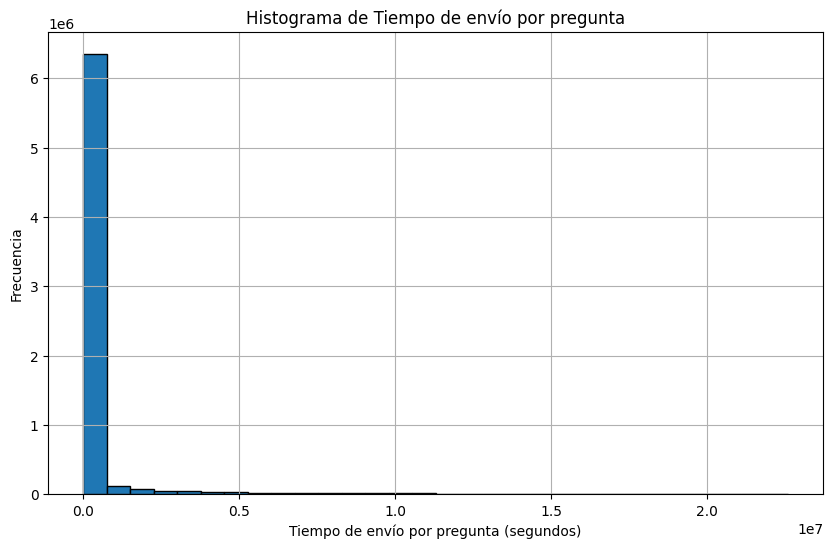

In [ ]:
plt.figure(figsize=(10, 6))  
plt.hist(df_respuestas['tiempo_respuesta'], bins=30, edgecolor='black')  
plt.title('Histograma de Tiempo de envío por pregunta')  
plt.xlabel('Tiempo de envío por pregunta (segundos)')  
plt.ylabel('Frecuencia')  
plt.grid(True)  
plt.show() 

Crendo la variable calificación

In [83]:
df_terminado = df_respuestas[df_respuestas['terminado'] == True]

# Crear una nueva columna 'calificacion' que contiene los puntos del problema
df_terminado['calificacion'] = df_terminado['problem_points']

# Identificar los usuarios que han participado en cada prueba
usuarios_con_registros = df_respuestas.groupby('contest_id')['handle'].nunique()

# Filtrar las pruebas en las que el usuario ha participado (es decir, tiene al menos un registro en la prueba)
df_terminado = df_terminado[df_terminado['contest_id'].isin(usuarios_con_registros[usuarios_con_registros > 0].index)]

# Agrupar por 'handle' (usuario) y 'contest_id' (prueba) y sumar los puntos obtenidos
df_calificaciones = df_terminado.groupby(['handle', 'contest_id'])['calificacion'].sum().reset_index()

# Mostrar el DataFrame resultante con las calificaciones por usuario y prueba
print(df_calificaciones)

C:\Users\carlo\AppData\Local\Temp\ipykernel_17508\1060401482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_terminado['calificacion'] = df_terminado['problem_points']


               handle  contest_id  calificacion
0             -------        1993         500.0
1             -------        1997           0.0
2             -------        1999           0.0
3             -------        2000           0.0
4             -------        2014           0.0
...               ...         ...           ...
1166749  zzzzzzzzzzzx        2027        2750.0
1166750  zzzzzzzzzzzx        2032        3250.0
1166751  zzzzzzzzzzzx        2033           0.0
1166752  zzzzzzzzzzzx        2036           0.0
1166753  zzzzzzzzzzzx        2043           0.0

[1166754 rows x 3 columns]


mergeando para tener una columna con la clasificación

In [84]:
df_finalisima = pd.merge(df_respuestas, df_calificaciones, on=['contest_id', 'handle'], how='left')


graficando la figura kernel para las calificaciones máximas y mínimas de los usuarios

In [85]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [87]:
import seaborn as sns

C:\Users\carlo\AppData\Local\Temp\ipykernel_17508\4207664668.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_calificaciones['calificacion'], label='Calificación', color='blue', shade=True)
C:\Users\carlo\AppData\Local\Temp\ipykernel_17508\4207664668.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_max_min['max_calificacion'], label='Clasificación Máxima', color='red', linestyle='--')
C:\Users\carlo\AppData\Local\Temp\ipykernel_17508\4207664668.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_max_min['min_calificacion'], label='Clasificación Mínima', color='green', linestyle='--')


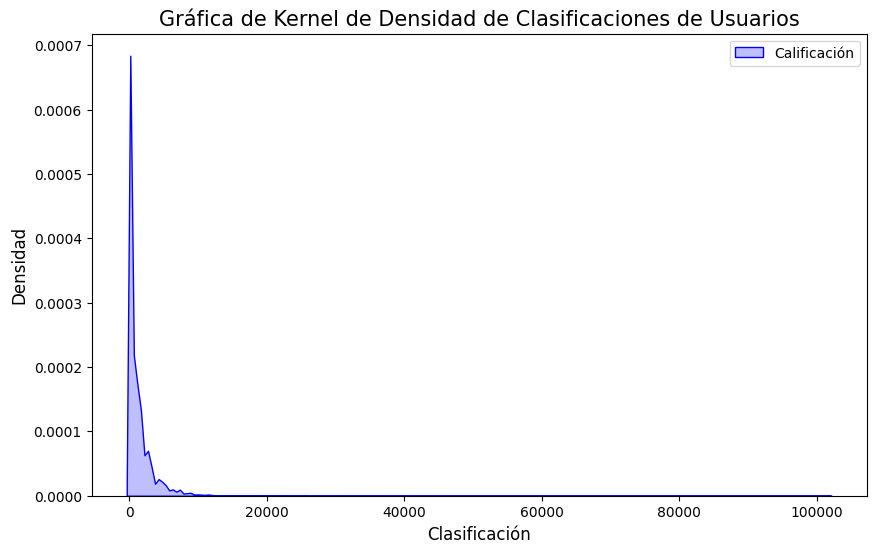

In [88]:
max_calificacion = df_calificaciones['calificacion'].max()
min_calificacion = df_calificaciones['calificacion'].min()

# Crear un DataFrame con las clasificaciones máxima y mínima (esto es opcional si deseas visualizarlas en la gráfica)
df_max_min = pd.DataFrame({
    'max_calificacion': [max_calificacion] * len(df_calificaciones),
    'min_calificacion': [min_calificacion] * len(df_calificaciones),
    'calificacion': df_calificaciones['calificacion']
})

# Configurar la figura de KDE
plt.figure(figsize=(10, 6))

# KDE para la columna 'calificacion'
sns.kdeplot(df_calificaciones['calificacion'], label='Calificación', color='blue', shade=True)

# KDE para la clasificación máxima
sns.kdeplot(df_max_min['max_calificacion'], label='Clasificación Máxima', color='red', linestyle='--')

# KDE para la clasificación mínima
sns.kdeplot(df_max_min['min_calificacion'], label='Clasificación Mínima', color='green', linestyle='--')

# Títulos y etiquetas
plt.title('Gráfica de Kernel de Densidad de Clasificaciones de Usuarios', fontsize=15)
plt.xlabel('Clasificación', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()

# Mostrar la gráfica
plt.show()

CREANDO EL BOX PLOT

In [89]:
df_respuestas.columns

Index(['contest_id', 'handle', 'problem_index', 'problem_name_x', 'verdict',
       'programming_language', 'time_consumed', 'memory_consumed', 'testset',
       'passed_tests', 'submission_time', 'problem_name_y', 'problem_type',
       'problem_points', 'problem_rating', 'terminado', 'name', 'type',
       'phase', 'frozen', 'durationSeconds', 'startTimeSeconds',
       'relativeTimeSeconds', 'freezeDurationSeconds', 'fecha',
       'relative_time', 'tiempo_respuesta'],
      dtype='object')

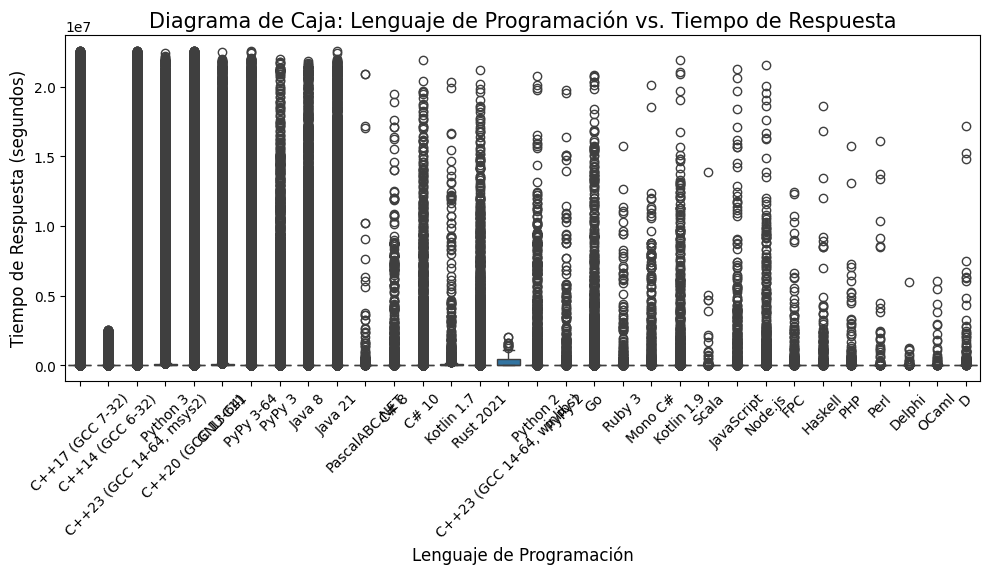

In [90]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_respuestas, x='programming_language', y='tiempo_respuesta')

# Títulos y etiquetas
plt.title('Diagrama de Caja: Lenguaje de Programación vs. Tiempo de Respuesta', fontsize=15)
plt.xlabel('Lenguaje de Programación', fontsize=12)
plt.ylabel('Tiempo de Respuesta (segundos)', fontsize=12)

# Mostrar el gráfico
plt.xticks(rotation=45)  # Rota las etiquetas de los lenguajes si es necesario
plt.tight_layout()  # Ajusta el gráfico para que todo sea visible
plt.show()

EXTRAYENDO MI DF FINAL

In [92]:
df_respuestas.to_csv('respuestas.csv', index=False)